In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jihyeseo/online-retail-data-set-from-uci-ml-repo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-data-set-from-uci-ml-repo' dataset.
Path to dataset files: /kaggle/input/online-retail-data-set-from-uci-ml-repo


In [34]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['Online Retail.xlsx']


In [35]:
['Online Retail.xlsx']

['Online Retail.xlsx']

In [36]:
file_path = os.path.join(path, "Online Retail.xlsx")

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [37]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [38]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [39]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [40]:
print("\nDuplicate Records:")
print(df.duplicated().sum())


Duplicate Records:
5268


In [41]:
df = df.dropna(subset=["CustomerID", "Description"])

print("Shape after removing missing values:")
print(df.shape)

Shape after removing missing values:
(406829, 8)


In [42]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Shape after removing cancelled orders:")
print(df.shape)

Shape after removing cancelled orders:
(397924, 8)


In [43]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Shape after removing invalid data:")
print(df.shape)

Shape after removing invalid data:
(397884, 8)


In [44]:
df = df.drop_duplicates()

print("Final cleaned dataset shape:")
print(df.shape)

Final cleaned dataset shape:
(392692, 8)


In [45]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [46]:
print("Final Dataset:")
print(df.head())

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())

Final Dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  

Rows: 392692
Columns: 9

Missing Values:
0


In [47]:
popular_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Most Purchased Products:")
print(popular_products)

Top 10 Most Purchased Products:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


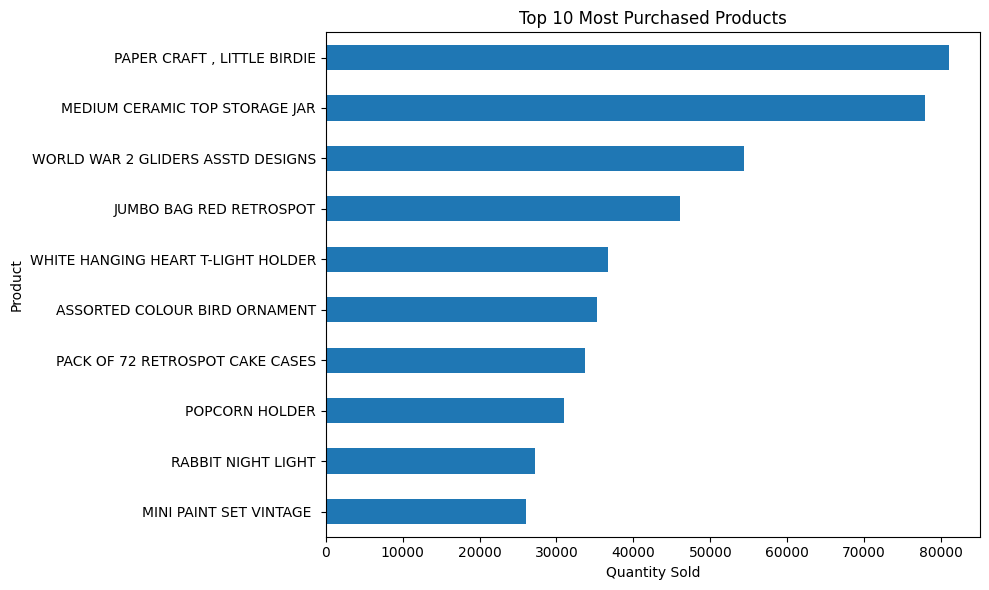

In [48]:
plt.figure(figsize=(10, 6))

popular_products.sort_values().plot(kind="barh")

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [49]:
customer_product_matrix = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print("Customer-Product Matrix:")
print(customer_product_matrix.shape)
print(customer_product_matrix.head())

Customer-Product Matrix:
(4338, 3877)
Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
CustomerID                                                                    
12346.0                                   0                               0   
12347.0                                   0                               0   
12348.0                                   0                               0   
12349.0                                   0                               0   
12350.0                                   0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
CustomerID                                                      
12346.0                       0                             0   
12347.0                       0                             0   
12348.0                       0                             0   
12349.0                       0                             0   
12350.0           

In [50]:
customer_product_matrix = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print("Customer-Product Matrix:")
print(customer_product_matrix.shape)
print(customer_product_matrix.head())

Customer-Product Matrix:
(4338, 3877)
Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
CustomerID                                                                    
12346.0                                   0                               0   
12347.0                                   0                               0   
12348.0                                   0                               0   
12349.0                                   0                               0   
12350.0                                   0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
CustomerID                                                      
12346.0                       0                             0   
12347.0                       0                             0   
12348.0                       0                             0   
12349.0                       0                             0   
12350.0           

In [51]:
def recommend_products(product_name, n=5):

    if product_name not in product_similarity.index:
        print("Product not found.")
        return

    recommendations = (
        product_similarity[product_name]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return recommendations

In [55]:
customer_product_matrix = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print("Customer-Product Matrix Shape:")
print(customer_product_matrix.shape)

Customer-Product Matrix Shape:
(4338, 3877)


In [56]:
product_customer_matrix = customer_product_matrix.T

print("Product-Customer Matrix Shape:")
print(product_customer_matrix.shape)

Product-Customer Matrix Shape:
(3877, 4338)


In [58]:
selected_product = popular_products.index[0]

print("Selected Product:")
print(selected_product)

recommendations = recommend_products(
    selected_product,
    5
)

print("\nRecommended Products:")

for i, (product, score) in enumerate(
    recommendations.items(),
    start=1
):
    print(
        f"{i}. {product} "
        f"- Similarity: {score:.4f}"
    )

Selected Product:
PAPER CRAFT , LITTLE BIRDIE

Recommended Products:
1. PANTRY PASTRY BRUSH - Similarity: 0.0072
2. PANTRY SCRUBBING BRUSH - Similarity: 0.0028
3. POLKADOT COFFEE CUP & SAUCER PINK - Similarity: 0.0000
4. POLKA DOT RAFFIA FOOD COVER - Similarity: 0.0000
5. POCKET MIRROR WOODLAND - Similarity: 0.0000
